In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from IPython.display import display, Markdown
from pandas import IndexSlice as S
from functools import lru_cache

In [2]:
df = pd.read_csv('data/pre-thin-data.csv')
df['status'] = df['pre_HT'].apply(lambda x: 'Alive' if pd.notnull(x) and x > 0 else 'Dead')
df.head()

,Row,Tree,pre_DBH,pre_HT,pre_LLC,pre_stem_vol,status
0,1,1,10.8,69.788672,NaN,19.593049,Alive
1,1,2,6.8,62.771152,NaN,7.127531,Alive
2,1,3,6.1,60.770923,NaN,5.601351,Alive
3,1,4,5.5,58.873375,NaN,4.458079,Alive
4,1,5,10.5,69.522875,NaN,18.461945,Alive


### Variable Thinning - based on Q4 Tree counts

In [3]:
def stand_analysis(df_thinned, metric='pre_DBH', vol_col='pre_stem_vol', status_col='status'):
    alive   = df_thinned[df_thinned[status_col] == 'Alive'].copy()
    kept    = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    pre_total_vol     = float(alive[vol_col].sum())   if len(alive) else 0.0
    post_total_vol    = float(kept[vol_col].sum())    if len(kept)  else 0.0
    removed_total_vol = float(removed[vol_col].sum()) if len(removed) else 0.0

    pre_median  = float(alive[metric].median()) if len(alive) else np.nan
    pre_mean    = float(alive[metric].mean())   if len(alive) else np.nan
    post_median = float(kept[metric].median())  if len(kept)  else np.nan
    post_mean   = float(kept[metric].mean())    if len(kept)  else np.nan
    d_median    = (post_median - pre_median) if (not np.isnan(post_median) and not np.isnan(pre_median)) else np.nan
    d_mean      = (post_mean   - pre_mean)   if (not np.isnan(post_mean)   and not np.isnan(pre_mean))   else np.nan

    q1 = alive[metric].quantile(0.25) if len(alive) else np.nan
    q3 = alive[metric].quantile(0.75) if len(alive) else np.nan

    L_pre  = int((alive [metric] <= q1).sum()) if len(alive) else 0
    H_pre  = int((alive [metric] >= q3).sum()) if len(alive) else 0
    L_post = int((kept  [metric] <= q1).sum()) if len(kept)  else 0
    H_post = int((kept  [metric] >= q3).sum()) if len(kept)  else 0

    L_cut = L_pre - L_post
    H_cut = H_pre - H_post

    removed_q4_vol = float(removed.loc[removed[metric] >= q3, vol_col].sum()) if len(removed) else 0.0
    pct_removed_vol_from_q4 = (100 * removed_q4_vol / removed_total_vol) if removed_total_vol > 0 else np.nan

    r_q4 = (H_post / H_pre) if H_pre > 0 else np.nan
    q1_removal_ratio = (L_cut / L_pre) if L_pre > 0 else np.nan

    total_removed = len(removed); total_kept = len(kept)

    return {
        '% trees removed': round((len(removed) / len(alive)) * 100, 2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2) if pre_total_vol > 0 else np.nan,
        'Trees kept': int(total_kept),
        'Trees removed': int(total_removed),

        'Q1 cut (count)': int(L_cut),
        'Q4 cut (count)': int(H_cut),
        'Q4 remaining (count)': int(H_post),

        '% of removed volume from Q4': round(pct_removed_vol_from_q4, 2) if not np.isnan(pct_removed_vol_from_q4) else np.nan,
        'Removed volume from Q4': round(removed_q4_vol, 2),

        'Q1 removal ratio (rem/pre)': round(q1_removal_ratio, 3) if not np.isnan(q1_removal_ratio) else np.nan,
        'Q1 pre (count)': int(L_pre),
        'Q4 pre (count)': int(H_pre),
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,

        'Post-thinning total volume': round(post_total_vol, 2),
        'Volume removed': round(removed_total_vol, 2),
        'Pre-thinning median DBH': round(pre_median, 2) if not np.isnan(pre_median) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean, 2)     if not np.isnan(pre_mean)   else np.nan,
        'Post-thinning median DBH': round(post_median, 2) if not np.isnan(post_median) else np.nan,
        'Post-thinning mean DBH': round(post_mean, 2)     if not np.isnan(post_mean)   else np.nan,
        'Change in median DBH': round(d_median, 2) if not np.isnan(d_median) else np.nan,
        'Change in mean DBH':   round(d_mean, 2)   if not np.isnan(d_mean)   else np.nan,
    }

def _row_quartile_counts(df, metric='pre_DBH', row_col='Row', status_col='status'):
    alive = df[df[status_col] == 'Alive'].copy()
    if alive.empty:
        raise ValueError("No Alive trees found; cannot compute quartiles.")

    q1 = float(alive[metric].quantile(0.25))
    q3 = float(alive[metric].quantile(0.75))

    alive['_is_q1'] = alive[metric] <= q1
    alive['_is_q4'] = alive[metric] >= q3

    rows = np.sort(pd.unique(df[row_col]))
    grp = alive.groupby(row_col, dropna=False)
    q1_counts = pd.Series(0, index=rows, dtype=int)
    q4_counts = pd.Series(0, index=rows, dtype=int)
    if not grp.obj.empty:
        q1_counts.loc[grp['_is_q1'].sum().index] = grp['_is_q1'].sum().astype(int).values
        q4_counts.loc[grp['_is_q4'].sum().index] = grp['_is_q4'].sum().astype(int).values

    return rows, q1, q3, q1_counts.values, q4_counts.values

def _best_sequence_from_start(rows, q1_counts, q4_counts, start_idx, target_cuts, steps=(3,4,5)):

    N = len(rows)
    if target_cuts <= 0 or start_idx < 0 or start_idx >= N:
        return None
    if start_idx + 3*(target_cuts-1) > N-1:
        return None

    from functools import lru_cache

    @lru_cache(maxsize=None)
    def dp(last_idx, selected):
        if selected == target_cuts:
            return (0, 0, ())
        remaining = target_cuts - selected
        if last_idx + 3*remaining > N-1:
            return None

        best = None
        cand = []
        for st in steps:
            nxt = last_idx + st
            if nxt <= N-1:
                cand.append((q4_counts[nxt], -q1_counts[nxt], st, nxt))
        cand.sort(key=lambda x: (x[0], x[1], x[2], x[3]))

        for q4c, neg_q1c, st, nxt in cand:
            rem_after = target_cuts - (selected + 1)
            if nxt + 3*rem_after > N-1:
                continue
            sub = dp(nxt, selected + 1)
            if sub is None:
                continue
            sub_q4, sub_q1, sub_path = sub
            cand_val = (q4c + sub_q4, (-neg_q1c) + sub_q1, (nxt,) + sub_path)
            if best is None:
                best = cand_val
            else:
                if (cand_val[0] < best[0]) or \
                   (cand_val[0] == best[0] and cand_val[1] > best[1]) or \
                   (cand_val[0] == best[0] and cand_val[1] == best[1] and cand_val[2] < best[2]):
                    best = cand_val
        return best

    start_cost = (q4_counts[start_idx], q1_counts[start_idx])
    sub = dp(start_idx, 1)
    if sub is None:
        return None
    sub_q4, sub_q1, sub_path = sub
    total_q4 = start_cost[0] + sub_q4
    total_q1 = start_cost[1] + sub_q1
    path = (start_idx,) + sub_path
    return (total_q4, total_q1, path)

def choose_variable_cut_rows(df, target_cuts:int, metric='pre_DBH',
                             row_col='Row', status_col='status',
                             first_start_rows:int=5,      #Gap rows in betweem take rows
                             min_in_between:int=2, max_in_between:int=4):

    assert min_in_between == 2 and max_in_between == 4, "Fixes gaps to [3,4,5]"
    rows, q1, q3, q1_counts, q4_counts = _row_quartile_counts(df, metric=metric, row_col=row_col, status_col=status_col)
    N = len(rows)
    if N == 0:
        return []

    max_start_idx = min(first_start_rows, N) - 1
    feasible_starts = [s for s in range(0, max_start_idx + 1) if s + 3*(target_cuts-1) <= N-1]
    if not feasible_starts:
        raise ValueError(f"Infeasible: cannot place {target_cuts} cut rows starting within first {first_start_rows} rows.")

    best_overall = None
    best_path = None
    for s in feasible_starts:
        res = _best_sequence_from_start(rows, q1_counts, q4_counts, s, target_cuts, steps=(3,4,5))
        if res is None:
            continue
        tot_q4, tot_q1, path = res
        key = (tot_q4, -tot_q1, s, path)
        if (best_overall is None) or (key < best_overall):
            best_overall = key
            best_path = path

    if best_path is None:
        raise ValueError("No feasible sequence found.")
    return rows[list(best_path)].tolist()

def variable_row_thinning(df, cut_rows, row_col='Row', status_col='status'):
    d = df.copy()
    d['thin_decision'] = 'Dead (ignored)'
    alive = d[status_col].eq('Alive')
    in_cut = d[row_col].isin(cut_rows)
    d.loc[alive & in_cut,  'thin_decision'] = 'Thin'
    d.loc[alive & ~in_cut, 'thin_decision'] = 'Keep'
    return d

def variable_thinning_variants(df, metric='pre_DBH', row_col='Row', status_col='status'):
    rows_sorted = np.sort(pd.unique(df[row_col]))
    R = len(rows_sorted)
    targets = {
        '3_row_equivalent' : R // 3,
        '4_row_equivalent' : R // 4,
        '5_row_equivalent' : R // 5,    
    }

    out = {}
    for label, m in targets.items():
        cuts = choose_variable_cut_rows(df, m, metric=metric, row_col=row_col, status_col=status_col,
                                        first_start_rows=5, min_in_between=2, max_in_between=4)
        d_thin = variable_row_thinning(df, cuts, row_col=row_col, status_col=status_col)
        out[label] = (cuts, d_thin)
    return out

def style_single_analysis_horizontal(report: dict, title: str = None):
    # Preferred column order
    show = [
        '% trees removed','% volume removed',
        'Trees kept','Trees removed',
        'Q1 cut (count)','Q1 removal ratio (removed/pre)',
        'Q4 remaining (count)','Q4 cut (count)',
        'Q4 retention ratio (post/pre)',
        '% of removed volume from Q4','Removed volume from Q4',
        'Volume removed','Post-thinning total volume',
        'Pre-thinning median DBH','Pre-thinning mean DBH',
        'Post-thinning median DBH','Post-thinning mean DBH',
        'Change in median DBH','Change in mean DBH'
    ]
    df_ = pd.DataFrame([report])
    cols = [c for c in show if c in df_.columns] + [c for c in df_.columns if c not in show]
    df_ = df_[cols]

    count_cols = ['Trees kept','Trees removed','Q1 cut (count)','Q4 cut (count)','Q4 remaining (count)']
    pct_cols   = ['% trees removed','% volume removed','% of removed volume from Q4']
    ratio_cols = ['Q4 retention ratio (post/pre)','Q1 removal ratio (removed/pre)']
    money_cols = ['Removed volume from Q4','Volume removed','Post-thinning total volume']
    num2_cols  = ['Pre-thinning mean DBH','Post-thinning mean DBH',
                  'Pre-thinning median DBH','Post-thinning median DBH',
                  'Change in median DBH','Change in mean DBH']

    sty = (df_.style
           .format({c:'{:,.0f}' for c in count_cols if c in df_})
           .format({c:'{:.2f}%' for c in pct_cols   if c in df_})
           .format({c:'{:.3f}'  for c in ratio_cols if c in df_})
           .format({c:'{:,.2f}' for c in money_cols if c in df_})
           .format({c:'{:,.2f}' for c in num2_cols  if c in df_})
           .set_caption(title or 'Stand analysis (variable thinning)')
           .hide(axis='index'))
    return sty


variants = variable_thinning_variants(
    df,
    metric='pre_DBH',
    row_col='Row',
    status_col='status'
)

for label, (cut_rows, d_thin) in variants.items():
    rep = stand_analysis(d_thin, metric='pre_DBH', vol_col='pre_stem_vol', status_col='status')
    rep['start_row'] = cut_rows[0] if len(cut_rows) else None  # optional info, not shown by default
    display(style_single_analysis_horizontal(rep, f'Variable thinning — {label}'))
    
    print(f'{label}: {cut_rows[:18]}')
    print('-'*140)


% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH,Q1 removal ratio (rem/pre),Q1 pre (count),Q4 pre (count),start_row
32.810000,31.940000,2027,990,277,573,241,0.704000,36.830000,4839.360000,13140.930000,28005.370000,8.90,8.98,8.90,9.03,0.00,0.05,0.352000,788,814,1


3_row_equivalent: [1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 47, 51, 54]
--------------------------------------------------------------------------------------------------------------------------------------------


% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH,Q1 removal ratio (rem/pre),Q1 pre (count),Q4 pre (count),start_row
25.620000,24.230000,2244,773,229,659,155,0.810000,31.170000,3107.030000,9968.120000,31178.180000,8.90,8.98,9.00,9.06,0.10,0.08,0.291000,788,814,2


4_row_equivalent: [2, 6, 10, 13, 18, 22, 26, 30, 33, 36, 39, 43, 47, 52, 56, 59]
--------------------------------------------------------------------------------------------------------------------------------------------


% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH,Q1 removal ratio (rem/pre),Q1 pre (count),Q4 pre (count),start_row
19.390000,18.150000,2432,585,182,699,115,0.859000,30.600000,2285.800000,7469.730000,33676.570000,8.90,8.98,9.00,9.04,0.10,0.07,0.231000,788,814,2


5_row_equivalent: [2, 6, 10, 13, 16, 19, 22, 26, 30, 33, 36, 39]
--------------------------------------------------------------------------------------------------------------------------------------------


### Variable Thinning - based on Q4 Treee volumes

#### **Based on Count:**

% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH,Q1 pre (count),Q4 pre (count),start_row
32.810000,31.940000,2027,990,277,0.352000,573,241,0.704000,36.830000,4839.360000,13140.930000,28005.370000,8.90,8.98,8.90,9.03,0.00,0.05,788,814,1


3_row_equivalent: [1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 47, 51, 54]
--------------------------------------------------------------------------------------------------------------------------------------------


% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH,Q1 pre (count),Q4 pre (count),start_row
25.620000,24.230000,2244,773,229,0.291000,659,155,0.810000,31.170000,3107.030000,9968.120000,31178.180000,8.90,8.98,9.00,9.06,0.10,0.08,788,814,2


4_row_equivalent: [2, 6, 10, 13, 18, 22, 26, 30, 33, 36, 39, 43, 47, 52, 56, 59]
--------------------------------------------------------------------------------------------------------------------------------------------


% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH,Q1 pre (count),Q4 pre (count),start_row
19.390000,18.150000,2432,585,182,0.231000,699,115,0.859000,30.600000,2285.800000,7469.730000,33676.570000,8.90,8.98,9.00,9.04,0.10,0.07,788,814,2


5_row_equivalent: [2, 6, 10, 13, 16, 19, 22, 26, 30, 33, 36, 39]
--------------------------------------------------------------------------------------------------------------------------------------------


#### **Based on Volume:**

% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH,Q1 pre (count),Q4 pre (count),start_row
33.280000,31.610000,2013,1004,297,0.377000,613,201,0.753000,31.290000,4070.230000,13007.900000,28138.410000,8.90,8.98,9.00,9.08,0.10,0.10,788,814,4


3_row_eqv cut rows: [4, 6, 8, 10, 12, 16, 18, 22, 26, 28, 30, 33, 36, 39, 43, 47, 51, 54]


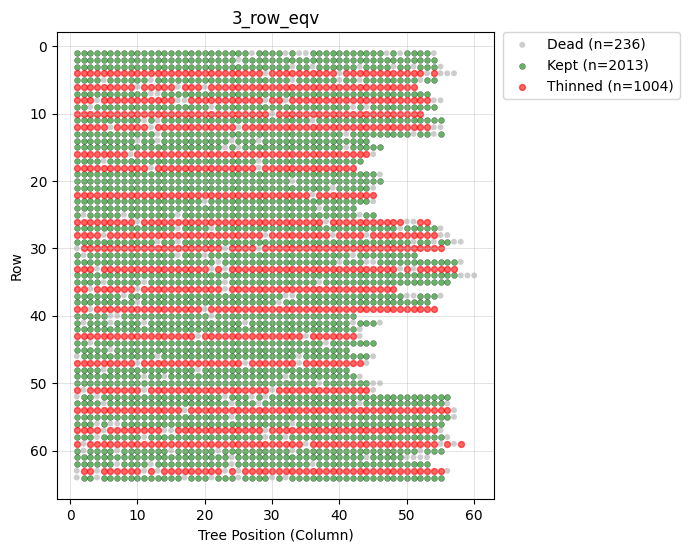

--------------------------------------------------------------------------------------------------------------------------------------------


% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH,Q1 pre (count),Q4 pre (count),start_row
25.490000,23.890000,2248,769,236,0.299000,663,151,0.814000,30.820000,3029.540000,9830.040000,31316.260000,8.90,8.98,9.00,9.07,0.10,0.09,788,814,2


4_row_eqv cut rows: [2, 4, 6, 8, 10, 12, 16, 18, 22, 24, 26, 28, 30, 33, 36, 39]


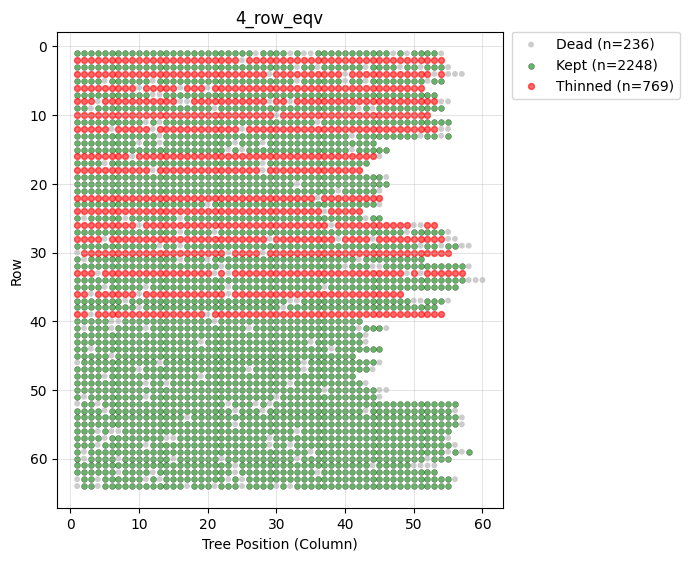

--------------------------------------------------------------------------------------------------------------------------------------------


% trees removed,% volume removed,Trees kept,Trees removed,Q1 cut (count),Q1 removal ratio (removed/pre),Q4 remaining (count),Q4 cut (count),Q4 retention ratio (post/pre),% of removed volume from Q4,Removed volume from Q4,Volume removed,Post-thinning total volume,Pre-thinning median DBH,Pre-thinning mean DBH,Post-thinning median DBH,Post-thinning mean DBH,Change in median DBH,Change in mean DBH,Q1 pre (count),Q4 pre (count),start_row
19.060000,17.790000,2442,575,173,0.220000,708,106,0.870000,29.150000,2133.250000,7318.110000,33828.200000,8.90,8.98,9.00,9.05,0.10,0.07,788,814,4


5_row_eqv cut rows: [4, 6, 10, 12, 16, 18, 22, 26, 28, 30, 33, 36]


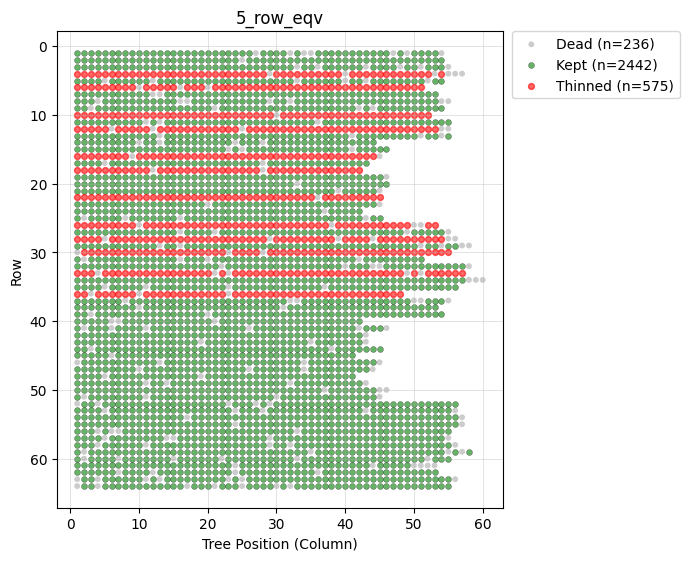

--------------------------------------------------------------------------------------------------------------------------------------------


In [4]:
def variable_row_thinning(df, cut_rows, row_col='Row', status_col='status'):
    d = df.copy()
    d['thin_decision'] = 'Dead (ignored)'
    alive = d[status_col].eq('Alive')
    in_cut = d[row_col].isin(cut_rows)
    d.loc[alive & in_cut,  'thin_decision'] = 'Thin'
    d.loc[alive & ~in_cut, 'thin_decision'] = 'Keep'
    return d

def stand_analysis(df_thinned, metric='pre_DBH', vol_col='pre_stem_vol', status_col='status'):
    alive   = df_thinned[df_thinned[status_col] == 'Alive'].copy()
    kept    = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    pre_total_vol     = float(alive[vol_col].sum())   if len(alive) else 0.0
    post_total_vol    = float(kept[vol_col].sum())    if len(kept)  else 0.0
    removed_total_vol = float(removed[vol_col].sum()) if len(removed) else 0.0

    pre_median  = float(alive[metric].median()) if len(alive) else np.nan
    pre_mean    = float(alive[metric].mean())   if len(alive) else np.nan
    post_median = float(kept[metric].median())  if len(kept)  else np.nan
    post_mean   = float(kept[metric].mean())    if len(kept)  else np.nan
    d_median    = (post_median - pre_median) if (not np.isnan(post_median) and not np.isnan(pre_median)) else np.nan
    d_mean      = (post_mean   - pre_mean)   if (not np.isnan(post_mean)   and not np.isnan(pre_mean))   else np.nan

    q1 = alive[metric].quantile(0.25) if len(alive) else np.nan
    q3 = alive[metric].quantile(0.75) if len(alive) else np.nan

    L_pre  = int((alive [metric] <= q1).sum()) if len(alive) else 0
    H_pre  = int((alive [metric] >= q3).sum()) if len(alive) else 0
    L_post = int((kept  [metric] <= q1).sum()) if len(kept)  else 0
    H_post = int((kept  [metric] >= q3).sum()) if len(kept)  else 0

    L_cut = L_pre - L_post
    H_cut = H_pre - H_post

    removed_q4_vol = float(removed.loc[removed[metric] >= q3, vol_col].sum()) if len(removed) else 0.0
    pct_removed_vol_from_q4 = (100 * removed_q4_vol / removed_total_vol) if removed_total_vol > 0 else np.nan

    r_q4 = (H_post / H_pre) if H_pre > 0 else np.nan
    q1_removal_ratio = (L_cut / L_pre) if L_pre > 0 else np.nan

    total_removed = len(alive) - len(kept)
    total_kept    = len(kept)

    return {
        '% trees removed': round((total_removed / len(alive)) * 100, 2) if len(alive) else np.nan,
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2) if pre_total_vol > 0 else np.nan,
        'Trees kept': int(total_kept),
        'Trees removed': int(total_removed),

        'Q1 cut (count)': int(L_cut),
        'Q4 cut (count)': int(H_cut),
        'Q4 remaining (count)': int(H_post),

        '% of removed volume from Q4': round(pct_removed_vol_from_q4, 2) if not np.isnan(pct_removed_vol_from_q4) else np.nan,
        'Removed volume from Q4': round(removed_q4_vol, 2),

        'Q1 removal ratio (removed/pre)': round(q1_removal_ratio, 3) if not np.isnan(q1_removal_ratio) else np.nan,
        'Q1 pre (count)': int(L_pre),
        'Q4 pre (count)': int(H_pre),
        'Q4 retention ratio (post/pre)': round(r_q4, 3) if not np.isnan(r_q4) else np.nan,

        'Post-thinning total volume': round(post_total_vol, 2),
        'Volume removed': round(removed_total_vol, 2),
        'Pre-thinning median DBH': round(pre_median, 2) if not np.isnan(pre_median) else np.nan,
        'Pre-thinning mean DBH': round(pre_mean, 2)     if not np.isnan(pre_mean)   else np.nan,
        'Post-thinning median DBH': round(post_median, 2) if not np.isnan(post_median) else np.nan,
        'Post-thinning mean DBH': round(post_mean, 2)     if not np.isnan(post_mean)   else np.nan,
        'Change in median DBH': round(d_median, 2) if not np.isnan(d_median) else np.nan,
        'Change in mean DBH':   round(d_mean, 2)   if not np.isnan(d_mean)   else np.nan,
    }

def _row_q4_volume_by_row(df, metric='pre_DBH', vol_col='pre_stem_vol',
                          row_col='Row', status_col='status'):

    alive = df[df[status_col] == 'Alive'].copy()
    if alive.empty:
        raise ValueError("No Alive trees found; cannot compute Q4 volumes.")

    q3 = float(alive[metric].quantile(0.75))
    rows = np.sort(pd.unique(df[row_col]))

    q4_rows = alive.loc[alive[metric] >= q3, [row_col, vol_col]]
    q4_vol_by_row = q4_rows.groupby(row_col)[vol_col].sum()
    q4_vol_by_row = q4_vol_by_row.reindex(rows, fill_value=0.0)

    return rows, q3, q4_vol_by_row.values

def _best_sequence_from_start_q4vol(rows, q4_vols, start_idx, target_cuts, steps=(3,4,5)):

    N = len(rows)
    if target_cuts <= 0 or start_idx < 0 or start_idx >= N:
        return None

    if start_idx + 3*(target_cuts-1) > N-1:
        return None

    @lru_cache(maxsize=None)
    def dp(last_idx, selected):
        if selected == target_cuts:
            return (0.0, ())
        remaining = target_cuts - selected
        if last_idx + 3*remaining > N-1:
            return None

        best = None
        cand = []
        for st in steps:
            nxt = last_idx + st
            if nxt <= N-1:
                cand.append((q4_vols[nxt], st, nxt))
        cand.sort(key=lambda x: (x[0], x[1], x[2]))

        for q4v, st, nxt in cand:
            rem_after = target_cuts - (selected + 1)
            if nxt + 3*rem_after > N-1:
                continue
            sub = dp(nxt, selected + 1)
            if sub is None:
                continue
            sub_q4, sub_path = sub
            cand_val = (q4v + sub_q4, (nxt,) + sub_path)
            if best is None or (cand_val[0] < best[0]) or \
               (cand_val[0] == best[0] and cand_val[1] < best[1]):
                best = cand_val
        return best

    start_cost = float(q4_vols[start_idx])
    sub = dp(start_idx, 1)
    if sub is None:
        return None
    sub_q4, sub_path = sub
    total_q4 = start_cost + sub_q4
    path = (start_idx,) + sub_path
    return (total_q4, path)

def choose_variable_cut_rows_q4volume(df, target_cuts:int, metric='pre_DBH', vol_col='pre_stem_vol',
                                      row_col='Row', status_col='status',
                                      first_start_rows:int=5,
                                      min_in_between:int=3, max_in_between:int=4):

    assert min_in_between == 2 and max_in_between == 4, "Fixes steps to {3,4,5}."
    rows, q3, q4_vols = _row_q4_volume_by_row(
        df, metric=metric, vol_col=vol_col, row_col=row_col, status_col=status_col
    )
    N = len(rows)
    if N == 0:
        return []

    max_start_idx = min(first_start_rows, N) - 1
    feasible_starts = [s for s in range(0, max_start_idx + 1) if s + 3*(target_cuts-1) <= N-1]
    if not feasible_starts:
        raise ValueError(f"Infeasible: cannot place {target_cuts} cuts starting within first {first_start_rows} rows.")

    best_total = None
    best_path = None
    best_start = None
    for s in feasible_starts:
        res = _best_sequence_from_start_q4vol(rows, q4_vols, s, target_cuts, steps=(2,3,4))
        if res is None:
            continue
        tot_q4, path = res
        if (best_total is None) or (tot_q4 < best_total) or (tot_q4 == best_total and s < best_start):
            best_total = tot_q4
            best_path = path
            best_start = s

    if best_path is None:
        raise ValueError("No feasible sequence found.")
    return rows[list(best_path)].tolist()

def variable_thinning_variants_volume_pure(df, metric='pre_DBH', vol_col='pre_stem_vol',
                                           row_col='Row', status_col='status'):

    rows_sorted = np.sort(pd.unique(df[row_col]))
    R = len(rows_sorted)
    targets = {
        '3_row_eqv'       : R // 3,
        '4_row_eqv'       : R // 4,
        '5_row_eqv' : R // 5,
        
    }

    out = {}
    for label, m in targets.items():
        cuts = choose_variable_cut_rows_q4volume(
            df, m, metric=metric, vol_col=vol_col, row_col=row_col, status_col=status_col,
            first_start_rows=5, min_in_between=2, max_in_between=4
        )
        d_thin = variable_row_thinning(df, cuts, row_col=row_col, status_col=status_col)
        out[label] = (cuts, d_thin)
    return out

def style_single_analysis_horizontal(report: dict, title: str = None):
    # Preferred column order
    show = [
        '% trees removed','% volume removed',
        'Trees kept','Trees removed',
        'Q1 cut (count)','Q1 removal ratio (removed/pre)',
        'Q4 remaining (count)','Q4 cut (count)',
        'Q4 retention ratio (post/pre)',
        '% of removed volume from Q4','Removed volume from Q4',
        'Volume removed','Post-thinning total volume',
        'Pre-thinning median DBH','Pre-thinning mean DBH',
        'Post-thinning median DBH','Post-thinning mean DBH',
        'Change in median DBH','Change in mean DBH'
    ]
    df_ = pd.DataFrame([report])
    cols = [c for c in show if c in df_.columns] + [c for c in df_.columns if c not in show]
    df_ = df_[cols]

    # Format groups
    count_cols = ['Trees kept','Trees removed','Q1 cut (count)','Q4 cut (count)','Q4 remaining (count)']
    pct_cols   = ['% trees removed','% volume removed','% of removed volume from Q4']
    ratio_cols = ['Q4 retention ratio (post/pre)','Q1 removal ratio (removed/pre)']
    money_cols = ['Removed volume from Q4','Volume removed','Post-thinning total volume']
    num2_cols  = ['Pre-thinning mean DBH','Post-thinning mean DBH',
                  'Pre-thinning median DBH','Post-thinning median DBH',
                  'Change in median DBH','Change in mean DBH']

    sty = (df_.style
           .format({c:'{:,.0f}' for c in count_cols if c in df_})
           .format({c:'{:.2f}%' for c in pct_cols   if c in df_})
           .format({c:'{:.3f}'  for c in ratio_cols if c in df_})
           .format({c:'{:,.2f}' for c in money_cols if c in df_})
           .format({c:'{:,.2f}' for c in num2_cols  if c in df_})
           .set_caption(title or 'Stand analysis (variable thinning)')
           .hide(axis='index'))
    return sty
    
def spatial_map(df_thinned, title):
    alive = df_thinned[df_thinned['status'] == 'Alive']
    kept = alive[alive['thin_decision'] == 'Keep']
    thinned = alive[alive['thin_decision'] == 'Thin']
    dead = df_thinned[df_thinned['status'] == 'Dead']

    fig, ax = plt.subplots(figsize=(7, 7))

    if not dead.empty:
        ax.scatter(dead['Tree'], dead['Row'], s=18, c='gray', alpha=0.4,
                   label=f'Dead (n={len(dead)})', edgecolors='none')

    if not kept.empty:
        ax.scatter(kept['Tree'], kept['Row'], s=18, c='green', alpha=0.6,
                   label=f'Kept (n={len(kept)})', edgecolors='k', linewidths=0.3, marker='o')

    if not thinned.empty:
        ax.scatter(thinned['Tree'], thinned['Row'], s=18, c='red', alpha=0.6,
                   label=f'Thinned (n={len(thinned)})', marker='o', linewidths=1.0)

    ax.invert_yaxis()
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Tree Position (Column)')
    ax.set_ylabel('Row')
    ax.set_title(title)
    ax.grid(True, linewidth=0.5, alpha=0.5)

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

variants_vol = variable_thinning_variants_volume_pure(
    df,
    metric='pre_DBH',
    vol_col='pre_stem_vol',
    row_col='Row',
    status_col='status'
)

display(Markdown("#### **Based on Count:**"))
for label, (cut_rows, d_thin) in variants.items():
    rep = stand_analysis(d_thin, metric='pre_DBH', vol_col='pre_stem_vol', status_col='status')
    rep['start_row'] = cut_rows[0] if len(cut_rows) else None  # optional info, not shown by default
    display(style_single_analysis_horizontal(rep, f'Variable thinning — {label}'))
    
    print(f'{label}: {cut_rows[:18]}')
    print('-'*140)
    
display(Markdown("#### **Based on Volume:**"))
for label, (cut_rows, d_thin) in variants_vol.items():
    rep = stand_analysis(d_thin, metric='pre_DBH', vol_col='pre_stem_vol', status_col='status')
    rep['start_row'] = cut_rows[0] if len(cut_rows) else None  # optional info, not shown by default
    display(style_single_analysis_horizontal(rep, f'Variable thinning — {label}'))

    print(f'{label} cut rows: {cut_rows[:18]}')
    spatial_map(d_thin, title=label)
    print('-'*140)
